# Analysis of Stiffness Matrix

Below code analyses the stiffness matrix obtained from the respective Kglobal.dat file generated during the solving phase.
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.



To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

[1.07478647e+04 2.32826228e+04 4.14545488e+05 8.69592007e+05
 1.74754075e+06 3.15309971e+06 6.32551758e+06 1.09553935e+07
 1.15919309e+07 1.56585697e+07]


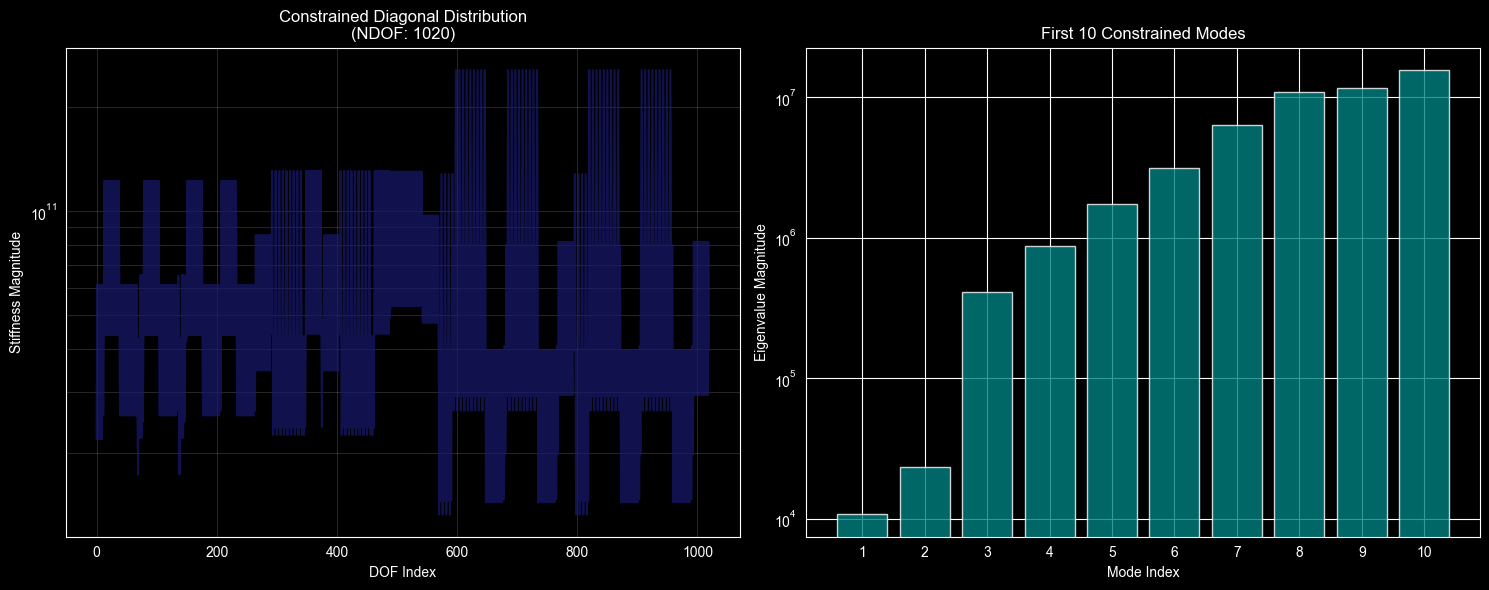

CONSTRAINED MATRIX AUDIT: K_final.mtx
Matrix Dimensions:  1020 x 1020
Symmetry Max Error: 0.00e+00
Global Trace:       6.151443e+13
Stiffness Spread:   1.93e+01 (Max/Min Diag)

Modal Density (Fundamental Modes):
  Mode 1: 1.074786e+04
  Mode 2: 2.328262e+04
  Mode 3: 4.145455e+05
  Mode 4: 8.695920e+05
  Mode 5: 1.747541e+06

Mode 2/1 Ratio:    2.166


In [3]:
import os
import numpy as np
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- 1. CONFIGURATION ---
os.chdir(r"C:\Calculix\ccx_2.23_wsl\Stiffness matrices\Scenario2 Full K")
filename = "K_final.mtx"

def audit_constrained_matrix(file_path):
    # --- 2. LOAD & RECONSTRUCT ---
    try:
        data = np.loadtxt(file_path)
        i, j, v = data[:, 0].astype(int) - 1, data[:, 1].astype(int) - 1, data[:, 2]
        ndof = int(max(i.max(), j.max()) + 1)

        K_ut = coo_matrix((v, (i, j)), shape=(ndof, ndof)).tocsr()
        # Full Reconstruction
        K = K_ut + K_ut.T - coo_matrix((K_ut.diagonal(), (range(ndof), range(ndof))), shape=(ndof, ndof)).tocsr()
    except Exception as e:
        print(f"Load Error: {e}")
        return

    # --- 3. NUMERICAL HEALTH ---
    diagonals = K.diagonal()
    # Check for Numerical Conditioning (Max/Min ratio)
    diag_min = diagonals[diagonals > 0].min()
    diag_max = diagonals.max()
    cond_proxy = diag_max / diag_min

    symmetry_error = (K - K.T).max()

    # --- 4. CONSTRAINED MODAL ANALYSIS ---
    # Since SPCs/MPCs are in, all 10 modes are "Elastic" (non-zero)
    vals, _ = eigsh(K, k=10, sigma=0, which="LM")
    vals = np.sort(np.abs(vals))
    print(vals)

    # --- 5. VISUALIZATION ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Subplot A: Diagonal Stiffness (Constraint Check)
    # High spikes often indicate MPC (Rigid Link) locations
    ax1.semilogy(diagonals, color='midnightblue', alpha=0.7)
    ax1.set_title(f"Constrained Diagonal Distribution\n(NDOF: {ndof})")
    ax1.set_xlabel("DOF Index")
    ax1.set_ylabel("Stiffness Magnitude")
    ax1.grid(True, which="both", ls="-", alpha=0.15)

    # Subplot B: Constrained Eigenvalues
    # No RBMs here; showing the spread of the first 10 structural modes
    ax2.bar(range(1, 11), vals, color='teal', alpha=0.8)
    ax2.set_yscale('log')
    ax2.set_title("First 10 Constrained Modes")
    ax2.set_xticks(range(1, 11))
    ax2.set_xlabel("Mode Index")
    ax2.set_ylabel("Eigenvalue Magnitude")

    plt.tight_layout()
    plt.show()

    # --- 6. CONSTRAINED REPORT ---
    print(f"{'='*50}")
    print(f"CONSTRAINED MATRIX AUDIT: {filename}")
    print(f"{'='*50}")
    print(f"Matrix Dimensions:  {ndof} x {ndof}")
    print(f"Symmetry Max Error: {symmetry_error:.2e}")
    print(f"Global Trace:       {diagonals.sum():.6e}")
    print(f"Stiffness Spread:   {cond_proxy:.2e} (Max/Min Diag)")
    print(f"\nModal Density (Fundamental Modes):")
    for idx, v in enumerate(vals[:5]):
        print(f"  Mode {idx+1}: {v:.6e}")

    # Calculate Ratio of Mode 2 to Mode 1 to see frequency separation
    print(f"\nMode 2/1 Ratio:    {vals[1]/vals[0]:.3f}")
    print(f"{'='*50}")

audit_constrained_matrix(filename)